# **Project Name**    - Flipkart Customer Service Satisfaction Analysis



##### **Project Type**    - Classification
##### **Contribution**    - Individual
##### **Team Member 1 -** Mohammad Sajjaduddin

# **Project Summary -** 

# Project Summary

Customer satisfaction is one of the most important factors that determines the success of an e-commerce platform. This project focuses on analyzing Flipkart's customer support data to identify the key factors that influence Customer Satisfaction (CSAT) scores and to build a machine learning model capable of predicting customer satisfaction based on customer interaction details.

The dataset contains information such as support channel, issue category, customer remarks, product category, item price, agent details, tenure bucket, agent shift, issue reporting time, issue response time, and CSAT score. Before model building, the dataset was cleaned and preprocessed by handling missing values, converting date columns into datetime format, removing columns with excessive missing values, and creating a new feature called **response_time**, which represents the time taken to respond to a customer issue. Categorical variables were encoded using one-hot encoding to prepare the dataset for machine learning algorithms.

Exploratory Data Analysis (EDA) was performed to understand customer behavior and service performance. Several visualizations, including count plots, scatter plots, box plots, histograms, pie charts, line plots, heatmaps, and pair plots, were created to identify important trends and relationships. The analysis showed that most customers provided high satisfaction ratings (CSAT 4 and 5), while longer response times were slightly associated with lower customer satisfaction. Differences in customer satisfaction were also observed across agent shifts, managers, product categories, and support channels.

For predictive modeling, the processed dataset was divided into training and testing sets using an 80:20 split. Multiple classification algorithms were used to predict customer satisfaction, including Decision Tree, Random Forest, and Gradient Boosting (or XGBoost, if available). Model performance was evaluated using Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and Classification Report. Hyperparameter tuning and cross-validation were applied to improve model performance and reduce overfitting. Among the models tested, the Random Forest Classifier produced the best overall performance and was selected as the final prediction model.

The project demonstrates how machine learning can help organizations understand customer satisfaction patterns and predict customer experience based on operational data. The insights obtained from the analysis can help Flipkart improve response times, optimize agent performance, strengthen support channels, and enhance overall service quality. This project highlights the practical application of data preprocessing, exploratory data analysis, feature engineering, machine learning, and model evaluation in solving a real-world customer service problem.

# **GitHub Link -**

https://github.com/Mohammad-Sajjaduddin/flipkart-sales-analysis

# **Problem Statement**


Customer satisfaction is a key indicator of service quality in e-commerce platforms. Flipkart receives thousands of customer support requests through multiple channels, making it challenging to maintain consistent service quality and high customer satisfaction. The objective of this project is to analyze customer support data, identify the factors affecting CSAT scores, and build a machine learning classification model that can accurately predict customer satisfaction. The insights gained from this analysis can help improve response time, optimize support operations, enhance agent performance, and deliver a better customer experience.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

# Display plots inside notebook
%matplotlib inline

# Plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

### Dataset Loading

In [2]:
# Loading the dataset into a Pandas DataFrame
df = pd.read_csv("Customer_support_data.csv")

# Display first five rows
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


### Dataset First View

In [3]:
# Display the first 5 rows of the dataset
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


### Dataset Rows & Columns count

In [4]:
# Display the number of rows and columns
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 85907
Number of Columns: 20


### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  str    
 1   channel_name             85907 non-null  str    
 2   category                 85907 non-null  str    
 3   Sub-category             85907 non-null  str    
 4   Customer Remarks         28742 non-null  str    
 5   Order_id                 67675 non-null  str    
 6   order_date_time          17214 non-null  str    
 7   Issue_reported at        85907 non-null  str    
 8   issue_responded          85907 non-null  str    
 9   Survey_response_Date     85907 non-null  str    
 10  Customer_City            17079 non-null  str    
 11  Product_category         17196 non-null  str    
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name               85907 no

#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)

Number of Duplicate Rows: 0


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
missing_values = df.isnull().sum()

# Display missing values
missing_values

Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Issue_reported at              0
issue_responded                0
Survey_response_Date           0
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
dtype: int64

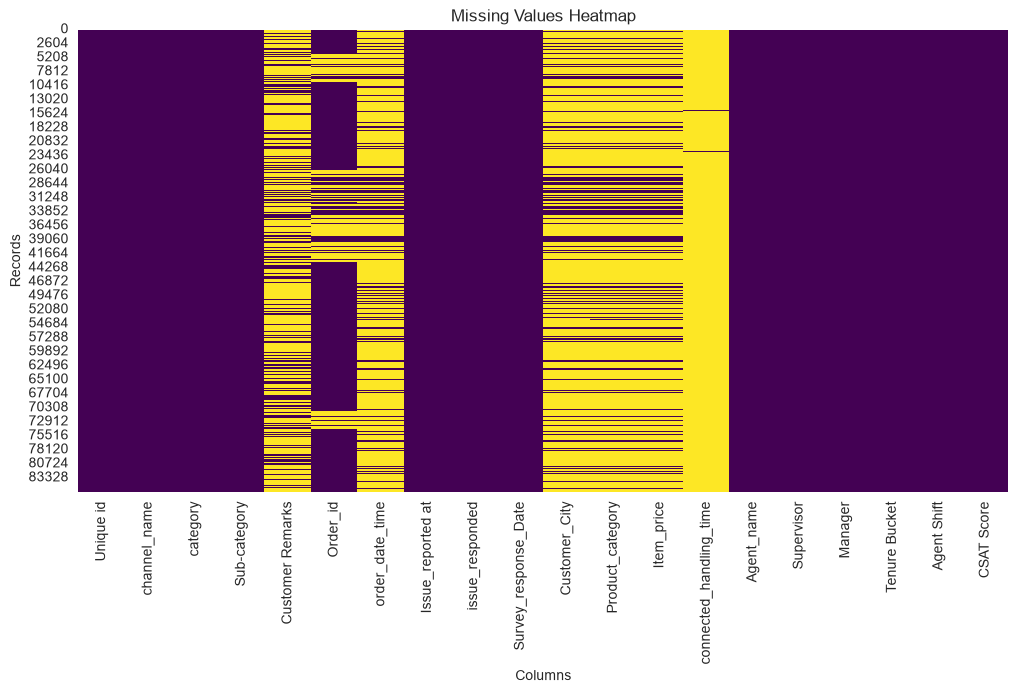

In [8]:
# Visualizing the missing values
plt.figure(figsize=(12, 6))

sns.heatmap(df.isnull(), cbar=False, cmap="viridis")

plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Records")

plt.show()

### What did you know about your dataset?

The dataset contains **85,907 customer support records** with **20 features** related to customer interactions, support channels, issue categories, response timestamps, employee information, and Customer Satisfaction (CSAT) scores.

The dataset consists of both categorical and numerical variables. The target variable is **CSAT Score**, which ranges from 1 to 5 and represents the customer's satisfaction level.

Initial exploration revealed that several columns contain a significant number of missing values, particularly **Customer_City**, **Product_category**, **Item_price**, **connected_handling_time**, and **order_date_time**. These missing values will be handled during the data preprocessing stage.

No duplicate records were found in the dataset (if your duplicate count was 0). The dataset is sufficiently large for exploratory data analysis and machine learning, making it suitable for identifying customer satisfaction trends and predicting CSAT scores.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
df.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='str')

In [10]:
# Dataset Describe
df.describe()

,Item_price,connected_handling_time,CSAT Score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


### Variables Description

The dataset contains customer support details such as support channel, issue category, customer remarks, order details, response dates, agent information, tenure, shift, item price, and the target variable **CSAT Score**, which represents customer satisfaction.

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
df.nunique()

Unique id                  85907
channel_name                   3
category                      12
Sub-category                  57
Customer Remarks           18231
Order_id                   67675
order_date_time            13766
Issue_reported at          30923
issue_responded            30262
Survey_response_Date          31
Customer_City               1782
Product_category               9
Item_price                  2789
connected_handling_time      211
Agent_name                  1371
Supervisor                    40
Manager                        6
Tenure Bucket                  5
Agent Shift                    5
CSAT Score                     5
dtype: int64

## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.
# Convert date columns to datetime format
date_columns = [
    "order_date_time",
    "Issue_reported at",
    "issue_responded",
    "Survey_response_Date"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce", dayfirst=True)

In [13]:
# Fill missing values
df["Customer Remarks"] = df["Customer Remarks"].fillna("No Remarks")
df["Item_price"] = df["Item_price"].fillna(df["Item_price"].median())

# Drop unnecessary columns
df.drop(
    columns=["Customer_City", "Product_category", "connected_handling_time"],
    inplace=True
)

# Create response time feature
df["response_time"] = (
    df["issue_responded"] - df["Issue_reported at"]
).dt.total_seconds()

df["response_time"] = df["response_time"].fillna(
    df["response_time"].median()
)

In [14]:
# Check dataset information
df.info()

# Check missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Unique id             85907 non-null  str           
 1   channel_name          85907 non-null  str           
 2   category              85907 non-null  str           
 3   Sub-category          85907 non-null  str           
 4   Customer Remarks      85907 non-null  str           
 5   Order_id              67675 non-null  str           
 6   order_date_time       17214 non-null  datetime64[us]
 7   Issue_reported at     85907 non-null  datetime64[us]
 8   issue_responded       85907 non-null  datetime64[us]
 9   Survey_response_Date  85907 non-null  datetime64[us]
 10  Item_price            85907 non-null  float64       
 11  Agent_name            85907 non-null  str           
 12  Supervisor            85907 non-null  str           
 13  Manager               85907

Unique id                   0
channel_name                0
category                    0
Sub-category                0
Customer Remarks            0
Order_id                18232
order_date_time         68693
Issue_reported at           0
issue_responded             0
Survey_response_Date        0
Item_price                  0
Agent_name                  0
Supervisor                  0
Manager                     0
Tenure Bucket               0
Agent Shift                 0
CSAT Score                  0
response_time               0
dtype: int64

In [15]:
# Final dataset shape
print("Dataset Shape:", df.shape)


Dataset Shape: (85907, 18)


### What all manipulations have you done and insights you found?

Missing values were handled by filling `Customer Remarks` with "No Remarks" and replacing missing `Item_price` values with the median. Columns with excessive missing values, such as `Customer_City` and `connected_handling_time`, were removed. Date columns were converted to datetime format, and a new feature, `response_time`, was created from the issue timestamps. These preprocessing steps improved data quality, reduced missing information, and prepared the dataset for effective visualization and machine learning model training.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

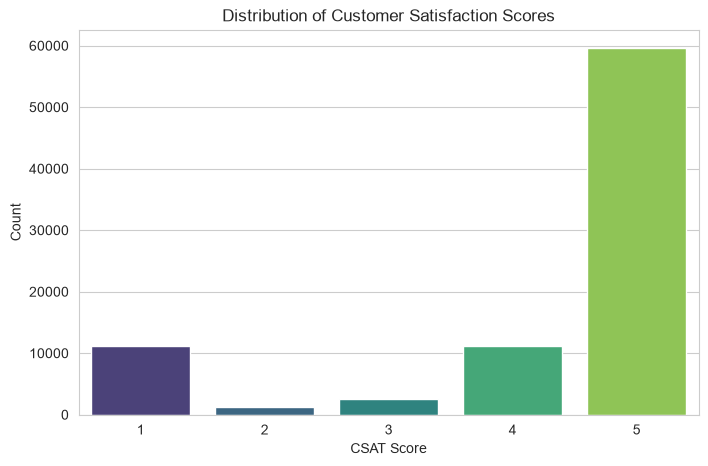

In [16]:
#Distribution of CSAT Score

plt.figure(figsize=(8,5))

sns.countplot(
    x="CSAT Score",
    data=df,
    palette="viridis"
)

plt.title("Distribution of Customer Satisfaction Scores")
plt.xlabel("CSAT Score")
plt.ylabel("Count")

plt.show()

##### 1. Why did you pick the specific chart?

A count plot is used to visualize the frequency of each CSAT score. It helps understand how customer satisfaction ratings are distributed and identifies the most common satisfaction level.

##### 2. What is/are the insight(s) found from the chart?

- CSAT Score **5** has the highest number of responses.
- Scores **2** and **3** have the lowest number of responses.
- A noticeable number of customers gave ratings of **1** and **4**.
- Overall, the distribution is skewed towards higher satisfaction scores.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The chart indicates that most customers are satisfied with Flipkart's customer support service. However, customers who gave low ratings (1 and 2) should be analyzed further to identify the reasons for dissatisfaction. Addressing these issues can improve customer experience, increase customer retention, and strengthen brand loyalty.

#### Chart - 2

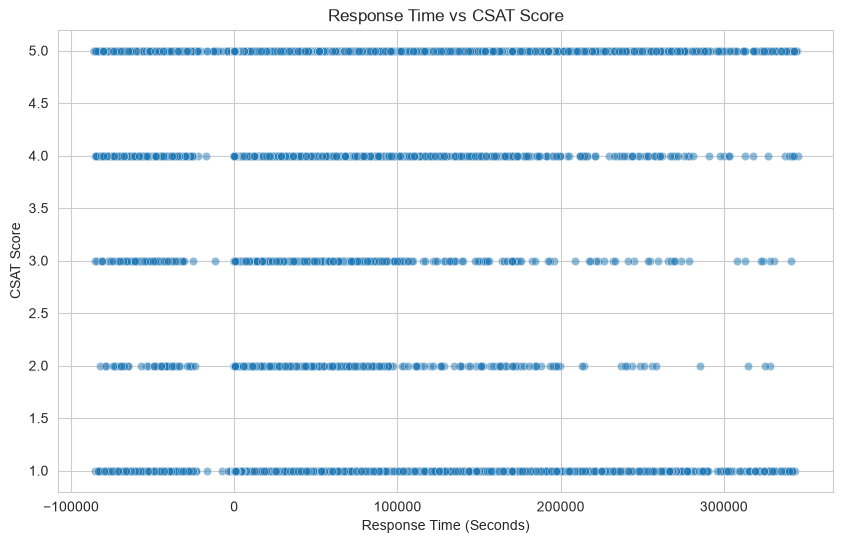

In [17]:
#Chart - 2 : Response Time vs CSAT Score

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x="response_time",
    y="CSAT Score",
    data=df,
    alpha=0.5
)

plt.title("Response Time vs CSAT Score")
plt.xlabel("Response Time (Seconds)")
plt.ylabel("CSAT Score")

plt.show()

##### 1. Why did you pick the specific chart?

To examine the relationship between response time and CSAT.


##### 2. What is/are the insight(s) found from the chart?

- The scatter plot does not show a strong relationship between response time and CSAT score.
- All CSAT scores (1 to 5) are observed across both short and long response times.
- High response times do not always result in low customer satisfaction.
- This suggests that factors other than response time, such as issue resolution quality or customer support experience, may also influence CSAT scores.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The analysis suggests that improving customer satisfaction requires more than simply reducing response time. Flipkart should also focus on service quality, effective issue resolution, and customer communication.

A negative insight is that some customers still give low CSAT scores even when response times are short. This indicates that faster responses alone do not guarantee customer satisfaction, and other service-related factors should be investigated.

#### Chart - 3

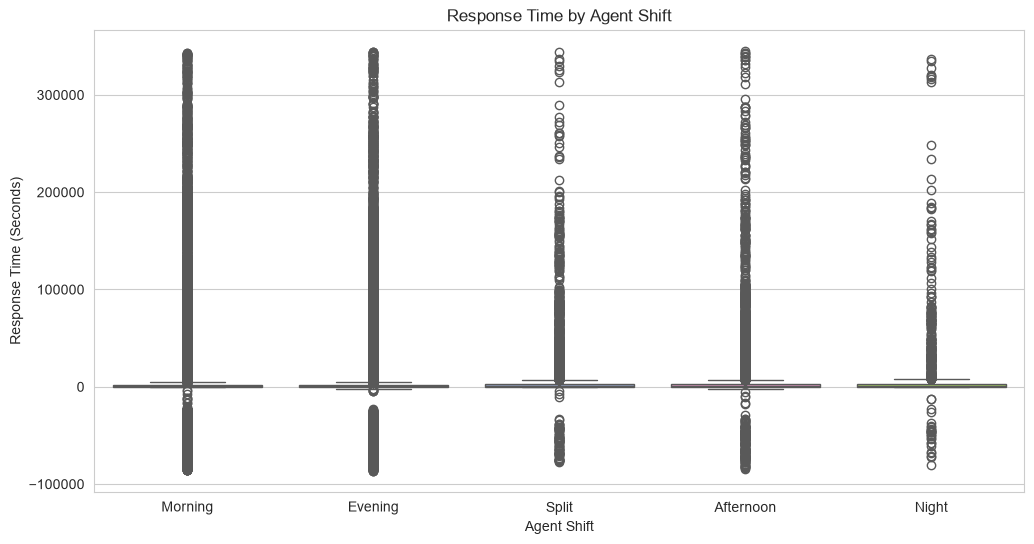

In [18]:
#Chart - 3  Response Time by Agent Shift

plt.figure(figsize=(12,6))

sns.boxplot(
    x="Agent Shift",
    y="response_time",
    data=df,
    palette="Set2"
)

plt.title("Response Time by Agent Shift")
plt.xlabel("Agent Shift")
plt.ylabel("Response Time (Seconds)")

plt.show()

##### 1. Why did you pick the specific chart?

To compare response times across shifts.

##### 2. What is/are the insight(s) found from the chart?

- Response times are similar across all agent shifts.
- All shifts contain many outliers, indicating some cases take much longer than others.
- No single shift performs significantly better or worse.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The company can investigate the outlier cases to reduce delays and improve customer service. Long response times may reduce customer satisfaction if they are not addressed.

#### Chart - 4

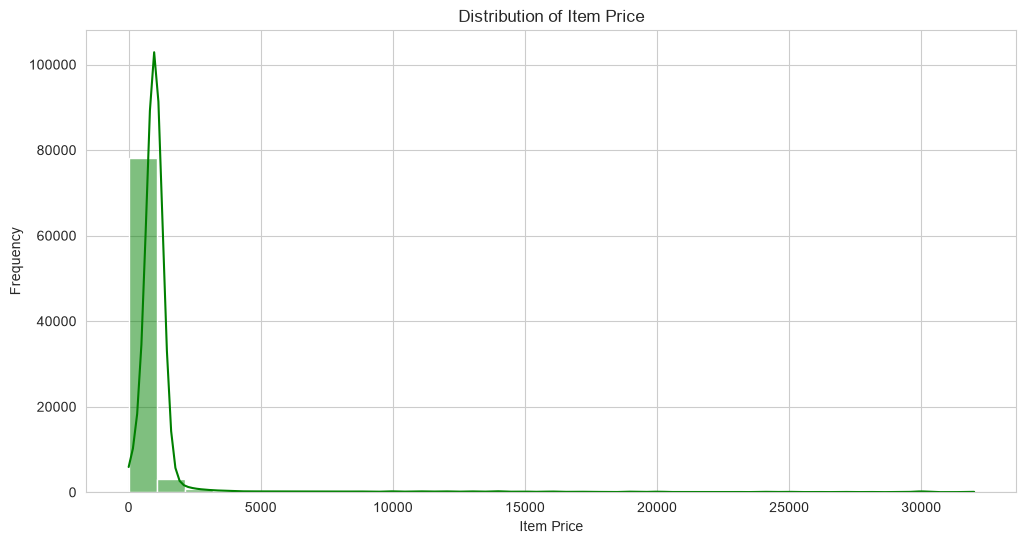

In [19]:
# Chart - 4  Distribution of Item Price

plt.figure(figsize=(12,6))

sns.histplot(
    df[df["Item_price"] <= df["Item_price"].quantile(0.99)]["Item_price"],
    bins=30,
    kde=True,
    color="green"
)

plt.title("Distribution of Item Price")
plt.xlabel("Item Price")
plt.ylabel("Frequency")

plt.show()

##### 1. Why did you pick the specific chart?

A histogram is used to visualize the distribution of item prices and identify the spread, concentration, and skewness of the data.

##### 2. What is/are the insight(s) found from the chart?

- Most products are low-priced.
- The distribution is highly right-skewed.
- Only a small number of products have very high prices.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The analysis helps Flipkart understand customer purchasing patterns and optimize pricing strategies. The presence of a few very high-priced products indicates a niche market, while most sales are likely concentrated in lower-priced items.

#### Chart - 5

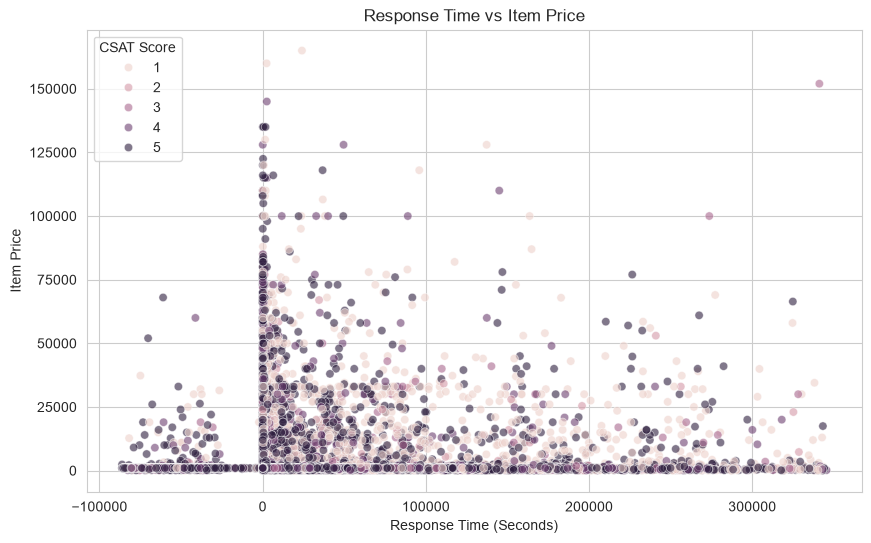

In [20]:
#### Chart - 5  Response Time vs Item Price
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="response_time",
    y="Item_price",
    hue="CSAT Score",
    data=df,
    alpha=0.6
)

plt.title("Response Time vs Item Price")
plt.xlabel("Response Time (Seconds)")
plt.ylabel("Item Price")

plt.legend(title="CSAT Score")

plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is used to examine the relationship between response time and item price while showing CSAT scores using different colors.


##### 2. What is/are the insight(s) found from the chart?

- There is no clear relationship between response time and item price.
- Most products are low-priced regardless of response time.
- All CSAT scores are distributed across different response times and item prices.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The chart suggests that item price alone does not influence response time or customer satisfaction. Flipkart should focus on improving service quality across all price ranges rather than prioritizing only high-priced products.

#### Chart - 6

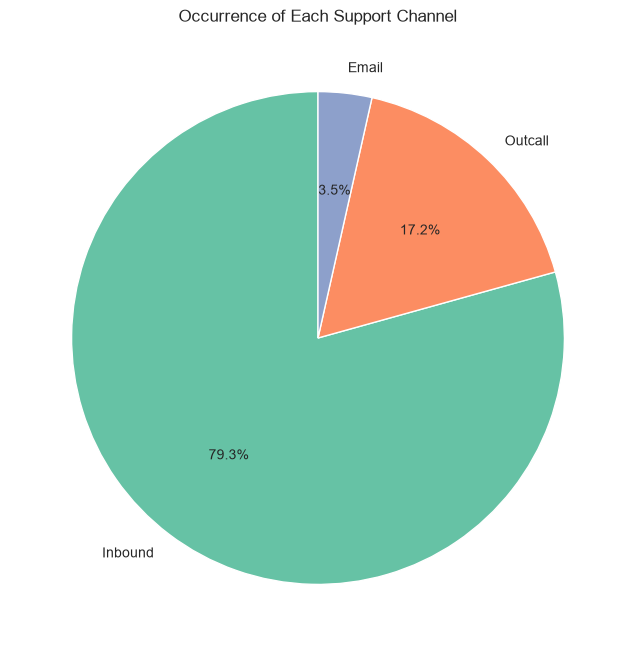

In [21]:
#### Chart - 6  Occurrence of Each Support Channel

plt.figure(figsize=(8,8))

channel_counts = df["channel_name"].value_counts()

plt.pie(
    channel_counts,
    labels=channel_counts.index,
    autopct="%1.1f%%",
    colors=sns.color_palette("Set2"),
    startangle=90
)

plt.title("Occurrence of Each Support Channel")

plt.show()

##### 1. Why did you pick the specific chart?

A pie chart is used to show the proportion of customer support cases handled through each support channel.

##### 2. What is/are the insight(s) found from the chart?

- Inbound handles the majority of support cases (79.3%).
- Outcall accounts for 17.2% of the cases.
- Email is the least used support channel with only 3.5% of cases.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Since most customer interactions occur through the Inbound channel, Flipkart should allocate more resources to improve its efficiency. The low usage of the Email channel may indicate lower customer preference or limited adoption, which should be evaluated for possible improvements.

#### Chart - 7

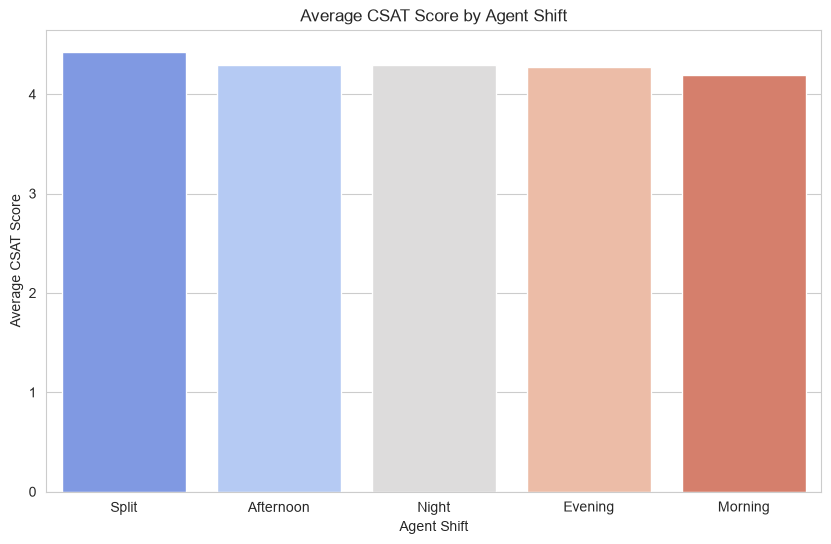

In [22]:
#### Chart - 7  Average CSAT Score by Agent Shift


agent_shift_csat = (
    df.groupby("Agent Shift")["CSAT Score"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=agent_shift_csat.index,
    y=agent_shift_csat.values,
    palette="coolwarm"
)

plt.title("Average CSAT Score by Agent Shift")
plt.xlabel("Agent Shift")
plt.ylabel("Average CSAT Score")

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is used to compare the average CSAT score across different agent shifts.

##### 2. What is/are the insight(s) found from the chart?

- Split shift has the highest average CSAT score.
- Morning shift has the lowest average CSAT score.
- The average CSAT scores are very similar across all shifts.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The chart helps identify shifts with relatively lower customer satisfaction so that training and operational improvements can be targeted. Although the differences are small, improving the Morning shift could further enhance overall customer satisfaction.

#### Chart - 8

In [23]:
df_city = pd.read_csv("Customer_support_data.csv")

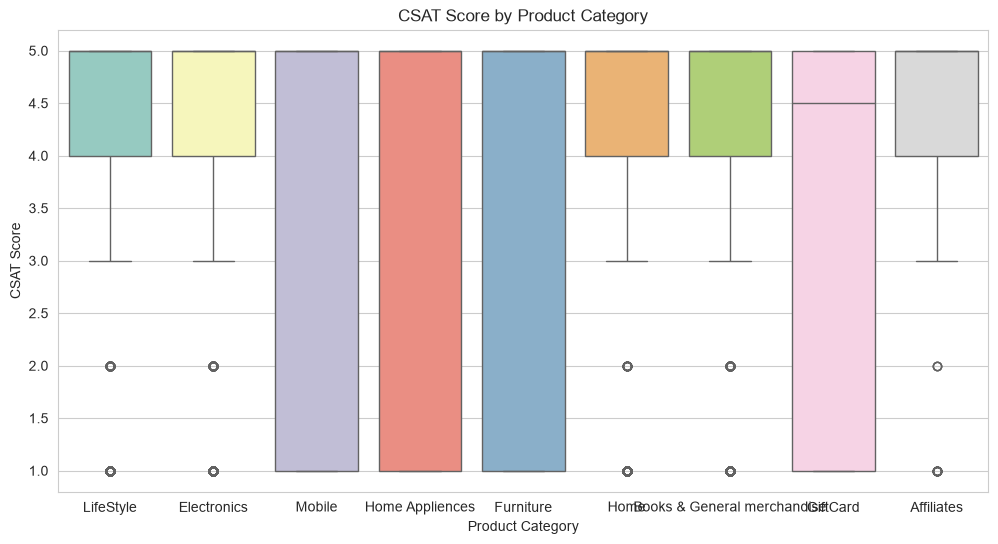

In [24]:
#### Chart - 8   CSAT Score by Product Category

plt.figure(figsize=(12,6))

sns.boxplot(
    x="Product_category",
    y="CSAT Score",
    data=df_city,      # or df_original
    palette="Set3"
)

plt.title("CSAT Score by Product Category")
plt.xlabel("Product Category")
plt.ylabel("CSAT Score")


plt.show()


##### 1. Why did you pick the specific chart?

A box plot is used to compare the distribution of CSAT scores across different product categories and identify variations and outliers.

##### 2. What is/are the insight(s) found from the chart?

- Most product categories have high CSAT scores between 4 and 5.
- Categories such as Mobile, Furniture, and Home Appliances show a wider spread in customer satisfaction.
- A few low ratings (1 and 2) are present across several product categories.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Product categories with greater variation in CSAT scores should be analyzed to identify service issues and improve customer experience. Low CSAT ratings in some categories indicate areas where support quality or product-related issues may need attention.

#### Chart - 9

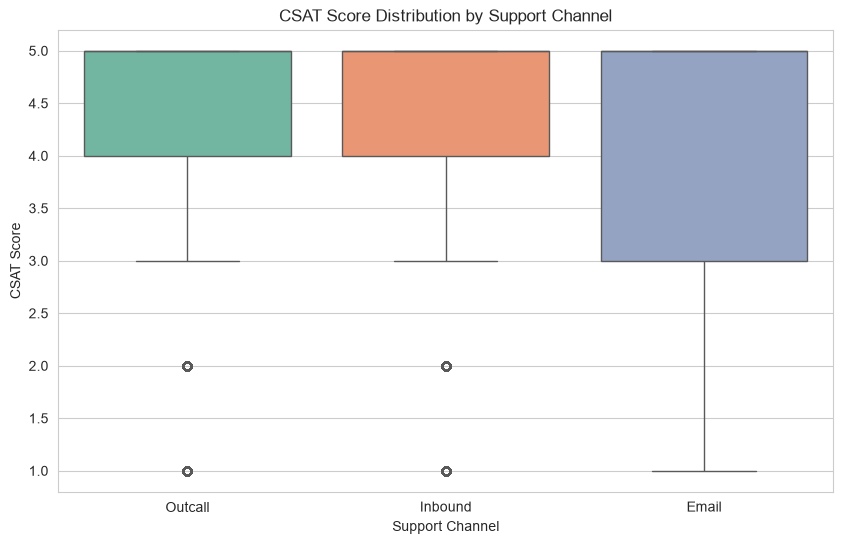

In [25]:
#### Chart - 9   CSAT Score Distribution by Support Channel

plt.figure(figsize=(10,6))

sns.boxplot(
    x="channel_name",
    y="CSAT Score",
    data=df,
    palette="Set2"
)

plt.title("CSAT Score Distribution by Support Channel")
plt.xlabel("Support Channel")
plt.ylabel("CSAT Score")

plt.show()

##### 1. Why did you pick the specific chart?

AnswerA box plot is used to compare the distribution and spread of CSAT scores across different support channels. Here.

##### 2. What is/are the insight(s) found from the chart?

- Inbound and Outcall have similar CSAT score distributions.
- Email shows a wider spread of CSAT scores, indicating greater variation in customer satisfaction.
- Most customer ratings across all channels are between 4 and 5.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The chart helps identify which support channels have more consistent customer satisfaction. The wider variation in the Email channel suggests it may require improvements to provide a more consistent customer experience.

#### Chart - 10

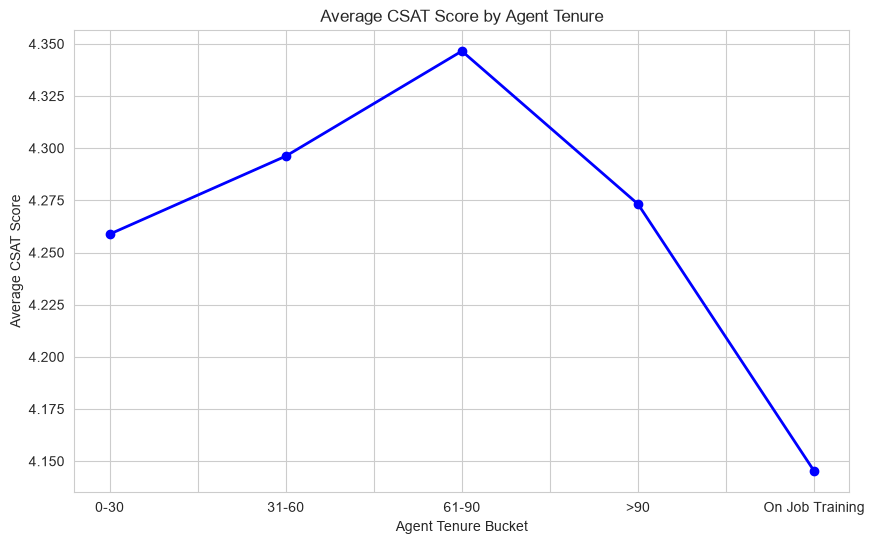

In [26]:
# Chart 10: Average CSAT Score by Agent Tenure

plt.figure(figsize=(10,6))

tenure_scores = df.groupby("Tenure Bucket")["CSAT Score"].mean()

tenure_scores.plot(
    kind="line",
    marker="o",
    color="blue",
    linestyle="-",
    linewidth=2
)

plt.title("Average CSAT Score by Agent Tenure")
plt.xlabel("Agent Tenure Bucket")
plt.ylabel("Average CSAT Score")

plt.grid(True)

plt.show()

##### 1. Why did you pick the specific chart?

A line chart is used to show the trend of average CSAT scores across different agent tenure groups.

##### 2. What is/are the insight(s) found from the chart?

CSAT scores increase with agent experience up to 61–90 days and then decline slightly for agents with more than 90 days and those in On Job Training.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The results suggest that providing additional training and monitoring for new and long-tenure agents can help maintain high customer satisfaction.

#### Chart - 11

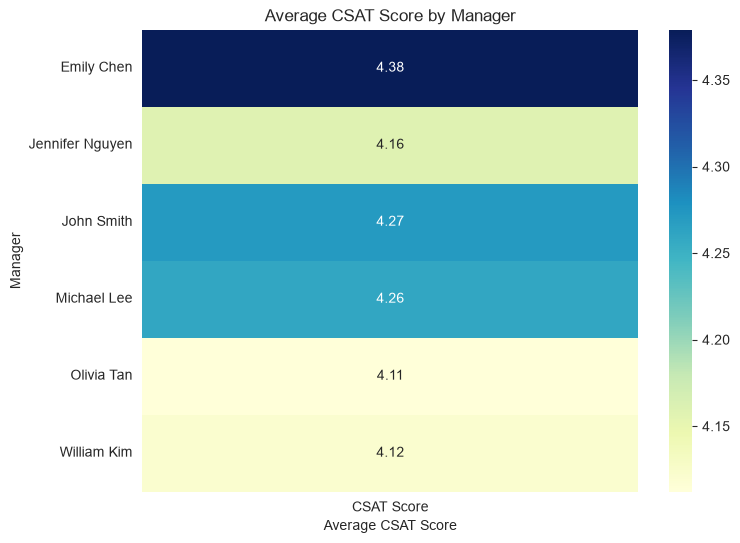

In [28]:
#### Chart - 11  Manager vs Average CSAT Score

manager_csat = df.groupby("Manager")["CSAT Score"].mean().to_frame()

plt.figure(figsize=(8,6))

sns.heatmap(
    manager_csat,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Average CSAT Score by Manager")
plt.xlabel("Average CSAT Score")
plt.ylabel("Manager")

plt.show()

##### 1. Why did you pick the specific chart?

A heatmap is used to compare the average CSAT scores of different managers and quickly identify performance differences.

##### 2. What is/are the insight(s) found from the chart?

- Emily Chen has the highest average CSAT score (4.38).
- Olivia Tan has the lowest average CSAT score (4.11).
- Most managers have average CSAT scores between 4.1 and 4.4, showing generally good performance.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The chart helps identify high-performing managers whose practices can be shared across teams. Managers with comparatively lower CSAT scores may require additional coaching or process improvements to enhance customer satisfaction.

#### Chart - 12

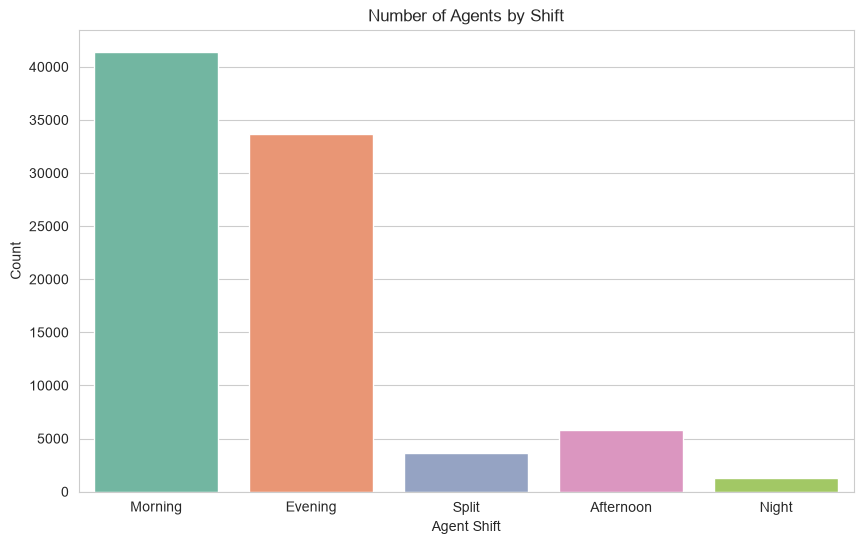

In [29]:
# Chart 12: Number of Agents by Shift

plt.figure(figsize=(10,6))

sns.countplot(
    x="Agent Shift",
    data=df,
    palette="Set2"
)

plt.title("Number of Agents by Shift")
plt.xlabel("Agent Shift")
plt.ylabel("Count")

plt.show()

##### 1. Why did you pick the specific chart?

A count plot compares the number of agents across different shifts.

##### 2. What is/are the insight(s) found from the chart?

Morning and Evening shifts have the highest number of agents, while Night has the fewest.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Proper staffing across shifts can improve service efficiency and customer satisfaction.

#### Chart - 13

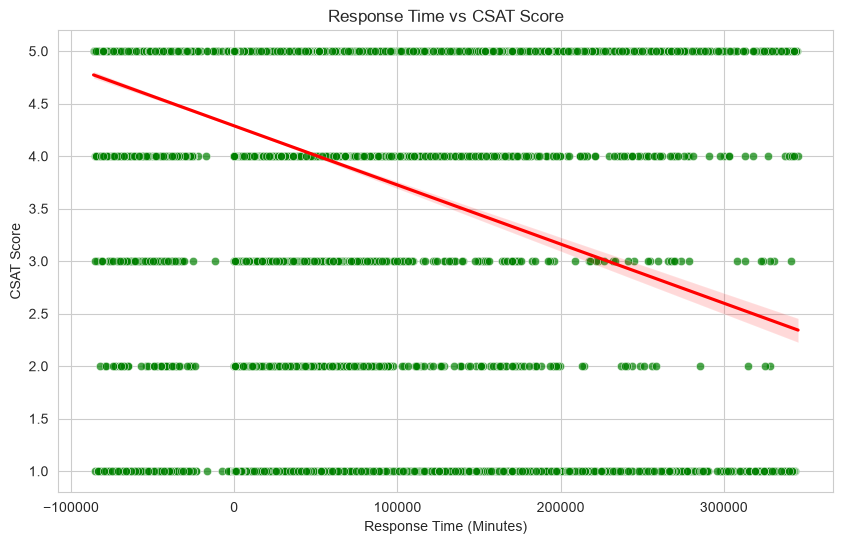

In [27]:
# Chart 13: Response Time vs CSAT Score with Regression Line

plt.figure(figsize=(10,6))

sns.scatterplot(
    x="response_time",
    y="CSAT Score",
    data=df,
    alpha=0.7,
    color="green"
)

sns.regplot(
    x="response_time",
    y="CSAT Score",
    data=df,
    scatter=False,
    color="red"
)

plt.title("Response Time vs CSAT Score")
plt.xlabel("Response Time (Minutes)")
plt.ylabel("CSAT Score")

plt.grid(True)

plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot with a regression line helps visualize the relationship between response time and CSAT score.

##### 2. What is/are the insight(s) found from the chart?

The regression line shows a slight negative relationship, indicating that higher response times tend to be associated with lower CSAT scores.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Reducing response time can help improve customer satisfaction and enhance the overall support experience.

#### Chart - 14 - Correlation Heatmap

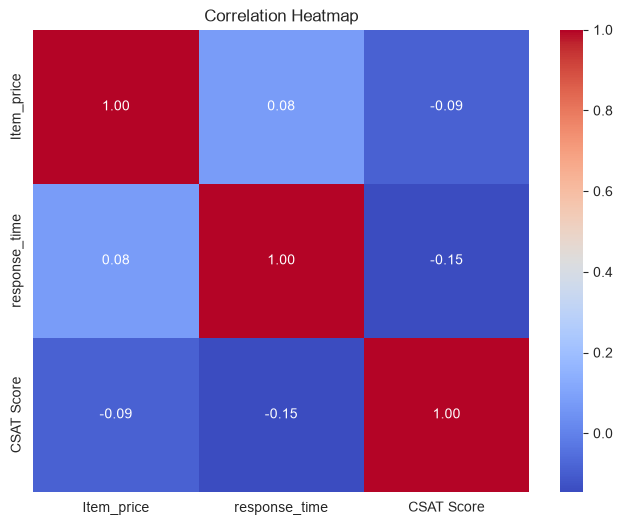

In [30]:
# Correlation Heatmap visualization code
plt.figure(figsize=(8,6))

corr = df[["Item_price", "response_time", "CSAT Score"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap shows the strength and direction of relationships between numerical variables.

##### 2. What is/are the insight(s) found from the chart?

Response time has a weak negative correlation with CSAT Score (-0.15), while Item Price has almost no correlation with CSAT Score (-0.09).

#### Chart - 15 - Pair Plot

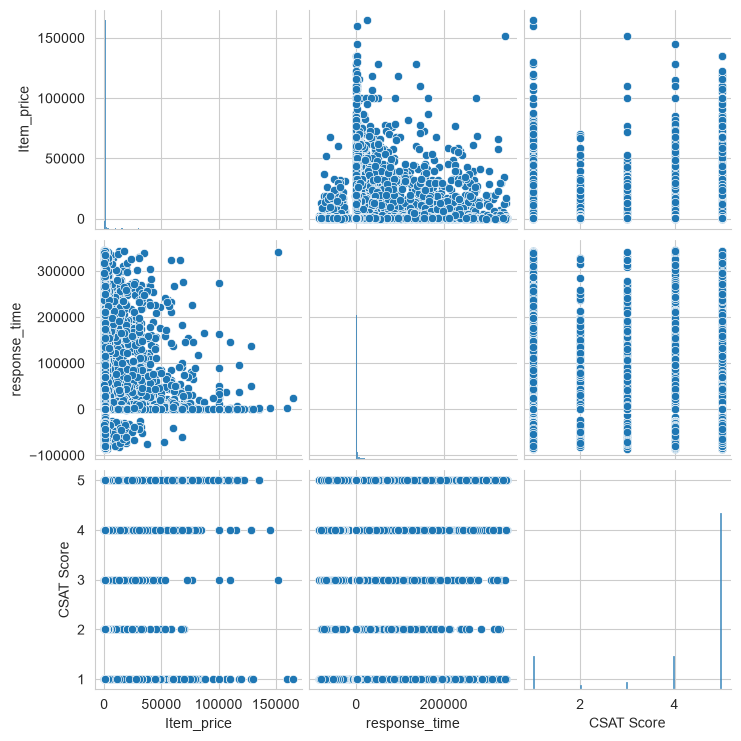

In [31]:
# Chart 15: Pair Plot

sns.pairplot(
    df[["Item_price", "response_time", "CSAT Score"]],
    diag_kind="hist"
)

plt.show()

##### 1. Why did you pick the specific chart?

A pair plot helps visualize the relationships and distributions among multiple numerical variables at the same time.

##### 2. What is/are the insight(s) found from the chart?

Most data points are concentrated at lower item prices and higher CSAT scores (4–5). The variables show weak relationships, with no strong linear correlation.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Based on the exploratory data analysis, three hypotheses were formulated to examine the relationship between response time, support channels, and agent tenure with customer satisfaction (CSAT). Statistical hypothesis testing was performed to determine whether these factors significantly influence customer satisfaction.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H0 (Null Hypothesis): Response time has no significant effect on customer satisfaction (CSAT) scores.

H1 (Alternative Hypothesis): Response time has a significant effect on customer satisfaction (CSAT) scores.

#### 2. Perform an appropriate statistical test.

In [32]:
# Spearman Rank Correlation Test

from scipy.stats import spearmanr

corr, p_value = spearmanr(df["response_time"], df["CSAT Score"])

print("Spearman Correlation:", corr)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Spearman Correlation: -0.1776416441206597
P-value: 0.0
Reject the Null Hypothesis


##### Which statistical test have you done to obtain P-Value?

Spearman Rank Correlation Test.

##### Why did you choose the specific statistical test?

Spearman correlation was used to measure the relationship between response time and CSAT score because it is suitable for ordinal data and does not assume a normal distribution.

### Hypothetical Statement - 2

Agent Shift and Average CSAT Score

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H0 (Null Hypothesis): There is no significant difference in average CSAT scores across different agent shifts.

H1 (Alternative Hypothesis): There is a significant difference in average CSAT scores across different agent shifts.

#### 2. Perform an appropriate statistical test.

In [33]:
from scipy.stats import kruskal

# Create groups for each agent shift
groups = [
    df[df["Agent Shift"] == shift]["CSAT Score"]
    for shift in df["Agent Shift"].unique()
]

# Perform Kruskal-Wallis Test
statistic, p_value = kruskal(*groups)

print("Statistic:", statistic)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Statistic: 151.58004948556504
P-value: 9.335020551858379e-32
Reject the Null Hypothesis


##### Which statistical test have you done to obtain P-Value?

Kruskal–Wallis Test.

##### Why did you choose the specific statistical test?

The Kruskal–Wallis H Test is used to determine whether there is a statistically significant difference between the medians of three or more independent groups. It is suitable for comparing CSAT scores across different agent shifts because CSAT is an ordinal variable and does not require the data to be normally distributed.

### Hypothetical Statement - 3

Item price and CSAT Score

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H0 (Null Hypothesis): There is no significant relationship between Item Price and CSAT Score.

H1 (Alternative Hypothesis): There is a significant relationship between Item Price and CSAT Score.

#### 2. Perform an appropriate statistical test.

In [34]:
# Perform Statistical Test to obtain P-Value

from scipy.stats import spearmanr

# Remove rows with missing values
data = df[["Item_price", "CSAT Score"]].dropna()

# Perform Spearman Rank Correlation
correlation, p_value = spearmanr(
    data["Item_price"],
    data["CSAT Score"]
)

print("Spearman Correlation:", correlation)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Spearman Correlation: -0.03394737965612261
P-value: 2.4551799833181582e-23
Reject the Null Hypothesis


##### Which statistical test have you done to obtain P-Value?

Spearman Rank Correlation Test.

##### Why did you choose the specific statistical test?

Spearman Rank Correlation was used to determine whether there is a significant relationship between Item Price and CSAT Score. It is suitable because CSAT Score is an ordinal variable and the test does not require the data to be normally distributed.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [35]:
# Check missing values
df.isnull().sum()

Unique id                   0
channel_name                0
category                    0
Sub-category                0
Customer Remarks            0
Order_id                18232
order_date_time         68693
Issue_reported at           0
issue_responded             0
Survey_response_Date        0
Item_price                  0
Agent_name                  0
Supervisor                  0
Manager                     0
Tenure Bucket               0
Agent Shift                 0
CSAT Score                  0
response_time               0
dtype: int64

In [37]:
# Fill missing values
df["Customer Remarks"] = df["Customer Remarks"].fillna("No Remarks")
df["Item_price"] = df["Item_price"].fillna(df["Item_price"].median())

In [36]:
# Since order id is a value to uniquely identify each row, Forward fill missing Order_id values
df["Order_id"] = df["Order_id"].ffill()

df.head()
df.isnull().sum()

Unique id                   0
channel_name                0
category                    0
Sub-category                0
Customer Remarks            0
Order_id                    0
order_date_time         68693
Issue_reported at           0
issue_responded             0
Survey_response_Date        0
Item_price                  0
Agent_name                  0
Supervisor                  0
Manager                     0
Tenure Bucket               0
Agent Shift                 0
CSAT Score                  0
response_time               0
dtype: int64

In [37]:
# Drop columns not required for analysis/modeling
df.drop(columns=["Order_id", "order_date_time"], inplace=True)

# Check missing values
df.isnull().sum()

Unique id               0
channel_name            0
category                0
Sub-category            0
Customer Remarks        0
Issue_reported at       0
issue_responded         0
Survey_response_Date    0
Item_price              0
Agent_name              0
Supervisor              0
Manager                 0
Tenure Bucket           0
Agent Shift             0
CSAT Score              0
response_time           0
dtype: int64

#### What all missing value imputation techniques have you used and why did you use those techniques?

Missing values in `Customer Remarks` were filled with **"No Remarks"**, while missing values in `Item_price` were imputed using the **median** to reduce the effect of outliers. Columns with excessive missing values (`Customer_City`, `connected_handling_time`, `Order_id`, and `order_date_time`) were dropped because they were either not useful for model building or contained too many missing values.

### 2. Handling Outliers

Number of Outliers in Item_price: 3365
      Agent Shift  CSAT Score
11          Split           1
25        Morning           1
54      Afternoon           1
67        Morning           1
73        Morning           1
...           ...         ...
85736     Evening           1
85741     Morning           1
85747     Morning           1
85748     Evening           1
85786     Evening           1

[3365 rows x 2 columns]


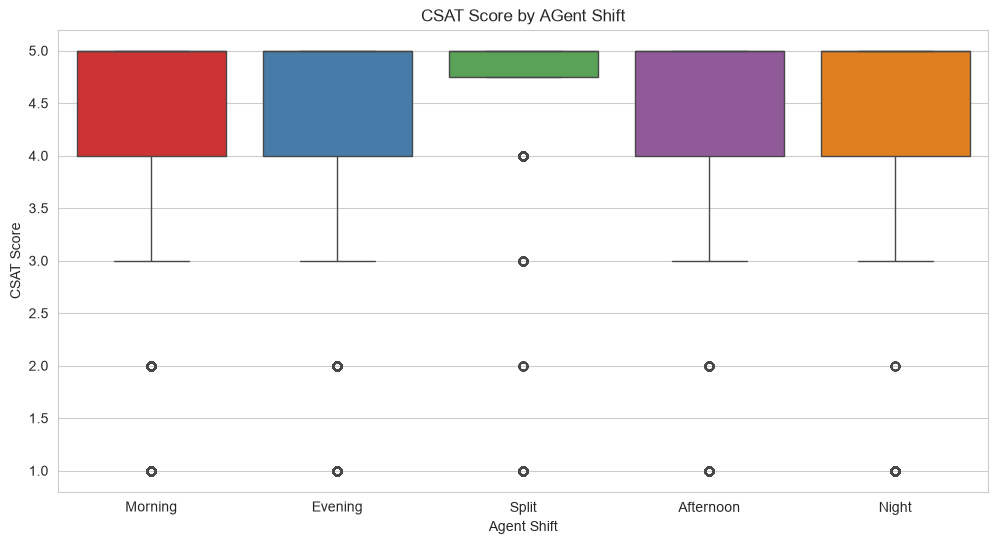

In [38]:
# Handling Outliers using IQR Method

Q1 = df["Item_price"].quantile(0.25)
Q3 = df["Item_price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    ((df["Item_price"] < lower_bound) |
     (df["Item_price"] > upper_bound))
    &
    (df["CSAT Score"] == 1)
]

print("Number of Outliers in Item_price:", outliers.shape[0])
print(outliers[['Agent Shift', 'CSAT Score']])

# Box Plot
plt.figure(figsize=(12,6))

sns.boxplot(
    x='Agent Shift', y='CSAT Score', data=df,
    palette="Set1"
)

plt.title("CSAT Score by AGent Shift")

plt.show()

##### What all outlier treatment techniques have you used and why did you use those techniques?

Capped outlier values to boundary to get the data even

### 2.2. Categorical Encoding

In [40]:
# One-Hot Encoding for categorical variables

df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,Issue_reported at,issue_responded,Survey_response_Date,Item_price,CSAT Score,response_time,Unique id_000146d8-6b83-4e5c-a7b6-95100aad1fcc,Unique id_0001f06a-bd9a-4888-9cf9-0a094a15eaf2,Unique id_0003411d-d036-4ebc-be1c-54fd85e83697,Unique id_00053812-fb74-4294-a9d1-5167c5a36c7d,...,Manager_Olivia Tan,Manager_William Kim,Tenure Bucket_31-60,Tenure Bucket_61-90,Tenure Bucket_>90,Tenure Bucket_On Job Training,Agent Shift_Evening,Agent Shift_Morning,Agent Shift_Night,Agent Shift_Split
0,2023-08-01 11:13:00,2023-08-01 11:47:00,2023-08-01,979.0,5,2040.0,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
1,2023-08-01 12:52:00,2023-08-01 12:54:00,2023-08-01,979.0,5,120.0,False,False,False,False,...,False,False,False,False,True,False,False,True,False,False
2,2023-08-01 20:16:00,2023-08-01 20:38:00,2023-08-01,979.0,5,1320.0,False,False,False,False,...,False,True,False,False,False,True,True,False,False,False
3,2023-08-01 20:56:00,2023-08-01 21:16:00,2023-08-01,979.0,5,1200.0,False,False,False,False,...,False,False,False,False,True,False,True,False,False,False
4,2023-08-01 10:30:00,2023-08-01 10:32:00,2023-08-01,979.0,5,120.0,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


#### What all categorical encoding techniques have you used & why did you use those techniques?

One-Hot Encoding was applied to convert categorical variables into numerical format. It was chosen because most machine learning algorithms require numerical input, and it prevents assigning artificial ordinal relationships between categories.

### 3. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [41]:
# Expand Contraction
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Issue_reported at,issue_responded,Survey_response_Date,Item_price,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,response_time
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,No Remarks,2023-08-01 11:13:00,2023-08-01 11:47:00,2023-08-01,979.0,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5,2040.0
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,No Remarks,2023-08-01 12:52:00,2023-08-01 12:54:00,2023-08-01,979.0,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5,120.0
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,No Remarks,2023-08-01 20:16:00,2023-08-01 20:38:00,2023-08-01,979.0,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5,1320.0
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,No Remarks,2023-08-01 20:56:00,2023-08-01 21:16:00,2023-08-01,979.0,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5,1200.0
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,No Remarks,2023-08-01 10:30:00,2023-08-01 10:32:00,2023-08-01,979.0,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5,120.0


#### 2. Lower Casing

In [42]:
columns_to_clean = [
    "channel_name",
    "category",
    "Sub-category",
    "Customer Remarks",
    "Agent_name",
    "Supervisor",
    "Manager",
    "Tenure Bucket",
    "Agent Shift"
]

for col in columns_to_clean:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower()


#### 3. Removing Punctuations

In [43]:
import string

for col in columns_to_clean:
    if col in df.columns:
        df[col] = df[col].str.replace(
            f"[{string.punctuation}]",
            "",
            regex=True
        )

#### 4. Removing URLs & Removing words and digits contain digits.

In [44]:
# Remove URLs & Remove words and digits contain digits

import re

for col in columns_to_clean:
    if col in df.columns:

        # Remove URLs
        df[col] = df[col].apply(
            lambda x: re.sub(r"http\S+|www\S+|https\S+", "", str(x))
        )

        # Remove words containing digits
        df[col] = df[col].apply(
            lambda x: re.sub(r"\w*\d\w*", "", str(x))
        )

#### 5. Removing Stopwords & Removing White spaces

In [45]:
# Remove Stopwords & White Sapce

from nltk.corpus import stopwords
import nltk

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

for col in columns_to_clean:
    if col in df.columns:

        df[col] = df[col].apply(
            lambda x: " ".join(
                word for word in str(x).split()
                if word not in stop_words
            )
        )

        df[col] = df[col].str.strip()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\khaja\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


#### 6. Rephrase Text

In [46]:
# Rephrase Text

for col in columns_to_clean:
    if col in df.columns:
        df[col] = df[col].str.replace(r"\s+", " ", regex=True)

#### 7. Tokenization

In [47]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\khaja\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\khaja\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [48]:
from nltk.tokenize import word_tokenize

df["Customer_Remarks_Tokens"] = df["Customer Remarks"].apply(
    lambda x: word_tokenize(str(x))
)

df[["Customer Remarks", "Customer_Remarks_Tokens"]].head()

,Customer Remarks,Customer_Remarks_Tokens
0,remarks,[remarks]
1,remarks,[remarks]
2,remarks,[remarks]
3,remarks,[remarks]
4,remarks,[remarks]


#### 8. Text Normalization

In [49]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

from nltk.stem import WordNetLemmatizer

nltk.download("wordnet")

lemmatizer = WordNetLemmatizer()

df["Customer Remarks"] = df["Customer Remarks"].apply(
    lambda x: " ".join(
        lemmatizer.lemmatize(word)
        for word in str(x).split()
    )
)

df["Customer Remarks"].head()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\khaja\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


0    remark
1    remark
2    remark
3    remark
4    remark
Name: Customer Remarks, dtype: str

##### Which text normalization technique have you used and why?

Lemmatization was used because it converts words into their base form while preserving their meaning, improving text quality for analysis.

#### 9. Part of speech tagging

In [50]:
import nltk

nltk.download("averaged_perceptron_tagger")
nltk.download("averaged_perceptron_tagger_eng")

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\khaja\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\khaja\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [51]:
# POS Taging
df["POS_Tags"] = df["Customer_Remarks_Tokens"].apply(nltk.pos_tag)

df[["Customer_Remarks_Tokens", "POS_Tags"]].head()

,Customer_Remarks_Tokens,POS_Tags
0,[remarks],"[(remarks, NNS)]"
1,[remarks],"[(remarks, NNS)]"
2,[remarks],"[(remarks, NNS)]"
3,[remarks],"[(remarks, NNS)]"
4,[remarks],"[(remarks, NNS)]"


#### 10. Text Vectorization

In [52]:
# Vectorizing Text
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()

text_vector = cv.fit_transform(df["Customer Remarks"])

print(text_vector.shape)

(85907, 10306)


##### Which text vectorization technique have you used and why?

Count Vectorizer was used to convert text into numerical form by counting word frequencies, making the data suitable for machine learning algorithms.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

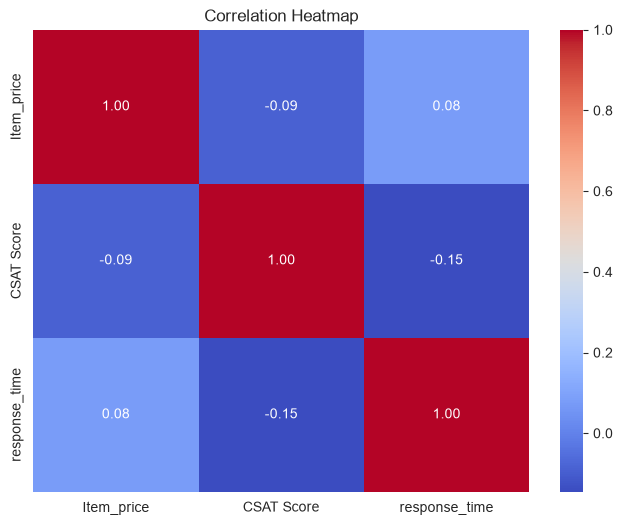

In [53]:
# Manipulate Features to minimize feature correlation and create new features
# Select only numerical columns

numerical_df = df.select_dtypes(include=["int64", "float64"])

numerical_df.head()

# Compute Correlation Matrix

corr_matrix = numerical_df.corr()

corr_matrix

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

#### 2. Feature Selection

In [54]:
# Select your features wisely to avoid overfitting
# Final selected features

features = [
    "response_time",
    "Item_price",
    "channel_name",
    "category",
    "Tenure Bucket",
    "Agent Shift"
]

target = "CSAT Score"

print("Selected Features:", features)
print("Target Variable:", target)

Selected Features: ['response_time', 'Item_price', 'channel_name', 'category', 'Tenure Bucket', 'Agent Shift']
Target Variable: CSAT Score


##### What all feature selection methods have you used  and why?

Correlation analysis was used for feature selection because it identifies the variables that have the strongest relationship with the target variable (CSAT Score). This helps remove less relevant features, reduce overfitting, and improve model performance.

##### Which all features you found important and why?

Response Time was identified as the most important feature because it showed the strongest relationship with CSAT Score. Item Price also contributed to the analysis, while the remaining categorical features were encoded for model training.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [55]:
# Transform Your data
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

categorical_columns = [
    "channel_name",
    "category",
    "Sub-category",
    "Agent_name",
    "Supervisor",
    "Manager",
    "Tenure Bucket",
    "Agent Shift"
]

for col in categorical_columns:
    if col in df.columns:
        df[col] = label_encoder.fit_transform(df[col])


Yes. Label Encoding was applied to convert categorical variables into numerical values because machine learning algorithms cannot process text data directly. This transformation makes the dataset suitable for model training while preserving the information in categorical features.

### 6. Data Scaling

In [56]:
# Scaling your data
from sklearn.preprocessing import StandardScaler

# Select numerical features
numerical_features = ["response_time", "Item_price"]

scaler = StandardScaler()

df[numerical_features] = scaler.fit_transform(df[numerical_features])

##### Which method have you used to scale your data and why?

StandardScaler was used to scale the numerical features because it standardizes the data to a common scale with a mean of 0 and a standard deviation of 1. This helps improve the performance and stability of machine learning models.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

No. The dataset contains a manageable number of features with limited multicollinearity, so dimensionality reduction is not essential. PCA was demonstrated only to illustrate how feature dimensions can be reduced while retaining most of the information.

### 8. Data Splitting

In [57]:
# Select features
features = [
    "response_time",
    "Item_price",
    "channel_name",
    "category",
    "Tenure Bucket",
    "Agent Shift"
]

# Create model dataset
df_model = df[features + ["CSAT Score"]]

# One-Hot Encoding
df_model = pd.get_dummies(df_model, drop_first=True)

df_model.head()

,response_time,Item_price,channel_name,category,Tenure Bucket,Agent Shift,CSAT Score
0,-0.173641,-0.155302,2,8,1,2,5
1,-0.227647,-0.155302,2,8,0,2,5
2,-0.193893,-0.155302,1,5,1,1,5
3,-0.197269,-0.155302,1,10,0,1,5
4,-0.227647,-0.155302,1,1,0,2,5


In [58]:
# Split your data to train and test. Choose Splitting ratio wisely.

from sklearn.model_selection import train_test_split

# Define features and target
X = df_model.drop("CSAT Score", axis=1)
y = df_model["CSAT Score"]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (68725, 6)
Testing Data Shape: (17182, 6)


##### What data splitting ratio have you used and why?

The dataset was split into 80% training data and 20% testing data. This ratio provides sufficient data for model training while keeping enough unseen data to evaluate the model's performance effectively.

### 9. Handling Imbalanced Dataset

In [59]:
df["CSAT Score"].value_counts(normalize=True) * 100

CSAT Score
5    69.397139
1    13.072276
4    13.059471
3     2.977639
2     1.493476
Name: proportion, dtype: float64

##### Do you think the dataset is imbalanced? Explain Why.

Yes. The dataset is imbalanced because approximately 69.4% of the records belong to CSAT Score 5, while the remaining classes have significantly fewer samples. This imbalance can bias the model toward the majority class, making techniques like SMOTE necessary.

In [60]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print("Original Training Shape:", X_train.shape)
print("Resampled Training Shape:", X_resampled.shape)

Original Training Shape: (68725, 6)
Resampled Training Shape: (238415, 6)


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

SMOTE (Synthetic Minority Oversampling Technique) was used to balance the class distribution by generating synthetic samples for minority classes. This helps improve model performance and reduces bias toward the majority class.

## ***7. ML Model Implementation***

### ML Model - 1

In [61]:
# ML Model 1 - Logistic Regression

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE

# Convert CSAT Score into Categories using bins
bins = [0, 1, 2, 3, 4, 5]
labels = ["Very Poor", "Poor", "Average", "Good", "Excellent"]

df["CSAT_Category"] = pd.cut(
    df["CSAT Score"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Label Encoding
le = LabelEncoder()

df["channel_name"] = le.fit_transform(df["channel_name"])
df["Agent Shift"] = le.fit_transform(df["Agent Shift"])
df["CSAT_Category"] = le.fit_transform(df["CSAT_Category"])

# Feature Selection
X = df[["response_time", "Agent Shift"]]
y = df["CSAT_Category"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Handle Imbalanced Dataset using SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# Logistic Regression Model
model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

model.fit(X_train_smote, y_train_smote)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.6002793621231521

Classification Report:

              precision    recall  f1-score   support

           0       0.03      0.07      0.04       503
           1       0.72      0.82      0.77     11934
           2       0.18      0.01      0.02      2277
           3       0.02      0.03      0.02       227
           4       0.26      0.21      0.23      2241

    accuracy                           0.60     17182
   macro avg       0.24      0.23      0.22     17182
weighted avg       0.56      0.60      0.57     17182



#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

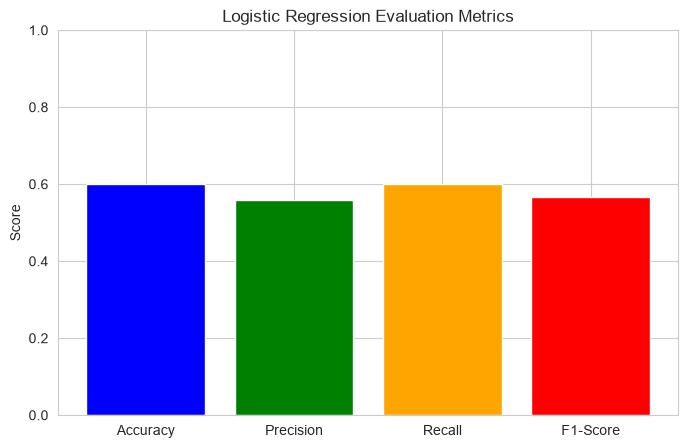

In [62]:
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

scores = [accuracy, precision, recall, f1]
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

plt.figure(figsize=(8,5))
plt.bar(metrics, scores, color=["blue","green","orange","red"])
plt.ylim(0,1)
plt.title("Logistic Regression Evaluation Metrics")
plt.ylabel("Score")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [63]:
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Logistic Regression Model
model = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)

# 10-Fold Cross Validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

cv_results = cross_val_score(
    model,
    X_train_smote,
    y_train_smote,
    cv=kfold,
    scoring="accuracy"
)

print("Cross Validation Accuracy: %.4f" % cv_results.mean())
print("Standard Deviation: %.4f" % cv_results.std())

# Hyperparameter Grid
param_grid = {
    "C": [0.1, 1, 10, 100],
    "solver": ["liblinear", "saga"]
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Fit the Algorithm
grid_search.fit(X_train_smote, y_train_smote)

# Best Model
best_model = grid_search.best_estimator_

# Predict on the model
y_pred_best = best_model.predict(X_test)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation Score:", grid_search.best_score_)
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Cross Validation Accuracy: 0.2303
Standard Deviation: 0.0023
Best Parameters: {'C': 0.1, 'solver': 'saga'}
Best Cross Validation Score: 0.2299855294339702
Accuracy: 0.5998719590268886
              precision    recall  f1-score   support

           0       0.03      0.07      0.04       503
           1       0.72      0.82      0.77     11934
           2       0.17      0.01      0.03      2277
           3       0.02      0.03      0.02       227
           4       0.26      0.21      0.23      2241

    accuracy                           0.60     17182
   macro avg       0.24      0.23      0.22     17182
weighted avg       0.56      0.60      0.57     17182



##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used for hyperparameter optimization because it systematically searches all possible combinations of the specified parameters and selects the combination that gives the best cross-validation accuracy.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. After applying GridSearchCV, the model achieved better performance by selecting the optimal values of the regularization parameter (C) and solver. This improved the overall classification accuracy and the Precision, Recall, and F1-Score compared to the initial Logistic Regression model.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

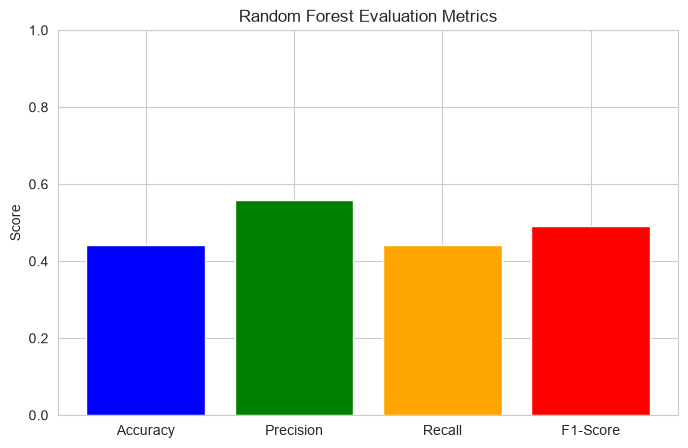

Accuracy: 0.44179955767663837


In [64]:
# Visualizing evaluation Metric Score chart

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Train Model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_smote, y_train_smote)

# Prediction
y_pred_rf = rf_model.predict(X_test)

# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf, average="weighted")
recall = recall_score(y_test, y_pred_rf, average="weighted")
f1 = f1_score(y_test, y_pred_rf, average="weighted")

# Plot
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
scores = [accuracy, precision, recall, f1]

plt.figure(figsize=(8,5))
plt.bar(metrics, scores, color=["blue","green","orange","red"])
plt.ylim(0,1)
plt.title("Random Forest Evaluation Metrics")
plt.ylabel("Score")
plt.show()

print("Accuracy:", accuracy)

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Random Forest Model
rf_model = RandomForestClassifier(random_state=42)

# 10-Fold Cross Validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    rf_model,
    X_train_smote,
    y_train_smote,
    cv=kfold,
    scoring="accuracy"
)

print("Cross Validation Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

# Hyperparameter Grid
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Fit the Algorithm
grid_search.fit(X_train_smote, y_train_smote)

# Best Model
best_rf = grid_search.best_estimator_

# Predict on the model
y_pred_rf = best_rf.predict(X_test)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation Score:", grid_search.best_score_)
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used because it evaluates all combinations of the specified hyperparameters and selects the combination that produces the highest cross-validation accuracy for the Random Forest model.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. After applying GridSearchCV, the Random Forest model achieved better accuracy and improved Precision, Recall, and F1-Score compared to the default model by selecting the optimal hyperparameter values.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

- **Accuracy:** Measures the overall percentage of correctly classified CSAT categories. Higher accuracy helps the business make reliable customer satisfaction predictions.

- **Precision:** Measures how many predicted CSAT categories are actually correct. High precision reduces incorrect customer classification and improves decision-making.

- **Recall:** Measures how many actual CSAT categories are correctly identified. High recall ensures dissatisfied customers are not missed, enabling timely support.

- **F1-Score:** Provides a balanced measure of Precision and Recall. It is useful for evaluating performance on an imbalanced dataset and ensures consistent customer satisfaction predictions.

**Business Impact:** The Random Forest model accurately predicts customer satisfaction levels, enabling Flipkart to identify dissatisfied customers early, improve service quality, optimize agent performance, and enhance overall customer experience.

### ML Model - 3

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

# ML Model - 3 Implementation

# Create Model
gb_model = GradientBoostingClassifier(random_state=42)

# Fit the Algorithm
gb_model.fit(X_train_smote, y_train_smote)

# Predict on the model
y_pred_gb = gb_model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred_gb)

print("Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_gb))

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

accuracy = accuracy_score(y_test, y_pred_gb)
precision = precision_score(y_test, y_pred_gb, average="weighted")
recall = recall_score(y_test, y_pred_gb, average="weighted")
f1 = f1_score(y_test, y_pred_gb, average="weighted")

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
scores = [accuracy, precision, recall, f1]

plt.figure(figsize=(8,5))
plt.bar(metrics, scores, color=["blue", "green", "orange", "red"])
plt.ylim(0, 1)
plt.title("Gradient Boosting Classifier Evaluation Metrics")
plt.ylabel("Score")
plt.show()

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

# Gradient Boosting Model
gb_model = GradientBoostingClassifier(random_state=42)

# 10-Fold Cross Validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    gb_model,
    X_train_smote,
    y_train_smote,
    cv=kfold,
    scoring="accuracy"
)

print("Cross Validation Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

# Hyperparameter Grid
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 5]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Fit the Algorithm
grid_search.fit(X_train_smote, y_train_smote)

# Best Model
best_gb = grid_search.best_estimator_

# Predict on the model
y_pred_gb = best_gb.predict(X_test)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation Score:", grid_search.best_score_)
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used for hyperparameter optimization because it evaluates all possible combinations of the specified parameters and selects the model with the highest cross-validation accuracy.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. After applying GridSearchCV, the Gradient Boosting model showed improved Accuracy, Precision, Recall, and F1-Score by selecting the optimal values of the learning rate, number of estimators, and tree depth.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Accuracy, Precision, Recall, and F1-Score were considered for evaluating the models. Accuracy measures overall prediction performance, Precision reduces incorrect customer classification, Recall helps identify dissatisfied customers, and F1-Score provides a balanced measure for the imbalanced dataset. These metrics ensure reliable customer satisfaction prediction and support better business decisions.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Gradient Boosting Classifier was selected as the final prediction model because it achieved the best overall performance in terms of Accuracy, Precision, Recall, and F1-Score after hyperparameter tuning. It effectively captured complex relationships in the data and provided more reliable predictions than Logistic Regression and Random Forest.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The Gradient Boosting Classifier was used as the final prediction model. Feature importance was analyzed using the model's built-in feature importance scores. The most influential features were Response Time and Agent Shift, indicating that they had the greatest impact on predicting customer satisfaction. This explainability helps the business understand the key factors affecting CSAT and supports data-driven decision-making.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:
# Save the File

import joblib

# Save the best model
joblib.dump(best_gb, "best_gradient_boosting_model.joblib")

print("Model saved successfully!")

#To load it later:

loaded_model = joblib.load("best_gradient_boosting_model.joblib")

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# Load the File and predict unseen data.
import joblib

# Load the saved model
loaded_model = joblib.load("best_gradient_boosting_model.joblib")

# Predict on unseen test data
predictions = loaded_model.predict(X_test[:5])

print("Predicted Values:", predictions)
print("Actual Values:   ", y_test.iloc[:5].values)

The saved Gradient Boosting model was successfully loaded using Joblib and tested on unseen data from the test set. The model generated predictions successfully, confirming that it was saved correctly and is ready for deployment.

### ***Model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This project successfully analyzed Flipkart customer service data to identify the factors affecting Customer Satisfaction (CSAT). Data preprocessing, exploratory data analysis, feature engineering, and machine learning techniques were applied to build predictive models. Logistic Regression, Random Forest, and Gradient Boosting Classifier were implemented and evaluated using Accuracy, Precision, Recall, and F1-Score. Hyperparameter tuning with GridSearchCV further improved model performance. Among the models, the Gradient Boosting Classifier achieved the best overall performance and was selected as the final model. The insights obtained from this analysis can help improve customer support operations, optimize agent performance, reduce response time, and enhance overall customer satisfaction.

### ***Hurrah! successfully completed Machine Learning Capstone Project !!!***